In [ ]:
# %pip install shap joblib

In [3]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import numpy as np

In [5]:
X_train = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/X_train.parquet')
X_test = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/X_test.parquet')
y_train = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/y_train.parquet').squeeze() # squeeze() turns 1-col DF back to Series
y_test = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/y_test.parquet').squeeze()


### **Global Explainability**

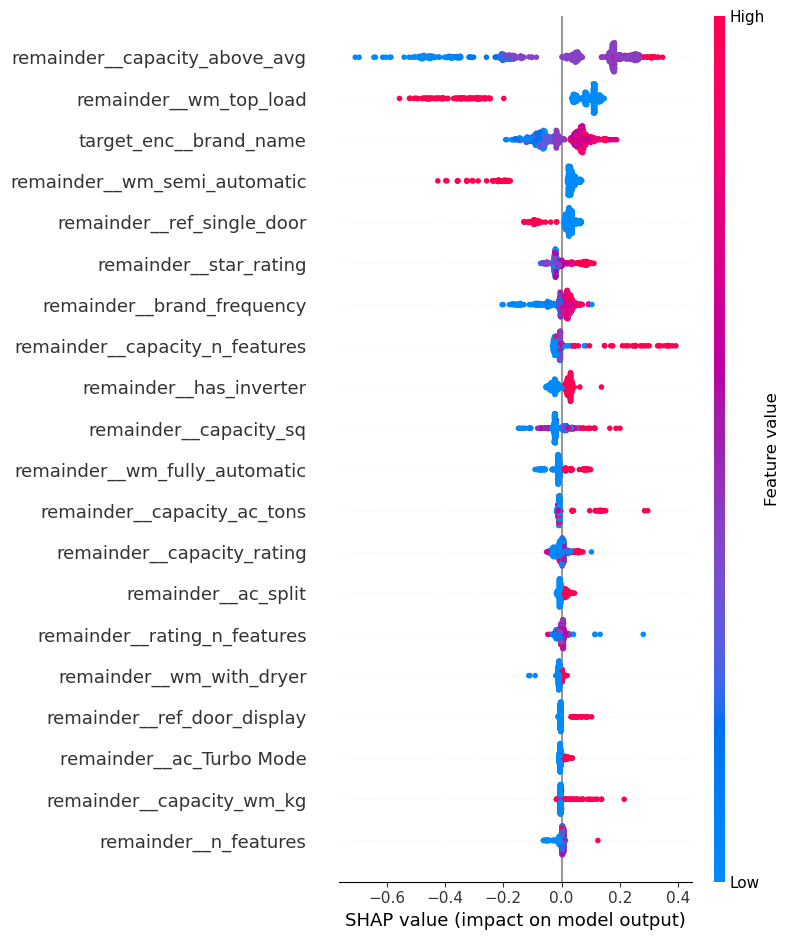

In [4]:
# 1. Load pipeline and data
pipeline = joblib.load('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/saved_models/multi_category_xgb_pipeline.pkl')
X_test = pd.read_parquet('D:/Study/data_science/Appliance Intelligence Price Tracker and Recommender/models/dataset/X_test.parquet')

# 2. Extract the model and the preprocessing steps from the pipeline
# SHAP needs the model and the data it sees *after* preprocessing
model = pipeline.named_steps['model'] 
preprocessor = pipeline.named_steps['preprocessor'] 

# 3. Transform the data
X_test_transformed = preprocessor.transform(X_test)

# If the transformed data is a sparse matrix, convert to dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get the feature names after transformation
feature_names = preprocessor.get_feature_names_out()

# IMPORTANT: Explicitly cast to float64 to avoid the 'object' dtype error
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names).astype(np.float64)

# 4. Initialize SHAP Explainer
# Using TreeExplainer for XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
# We use .values to pass the raw numpy array to avoid Pandas dtype overhead
shap_values = explainer.shap_values(X_test_transformed_df.values)

# 5. Summary Plot
plt.figure(figsize=(12, 8))
# Pass the DataFrame for feature names, and the calculated shap_values
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="dot")

SHAP analysis revealed that appliance capacity was the most influential determinant of price predictions. Features associated with premium products, including higher energy ratings, inverter technology, reputable brands, and increased functionality, generally contributed positively to predicted prices. Conversely, characteristics representing budget-oriented products, such as top-load and semi-automatic washing machines and single-door refrigerators, reduced predicted prices. The consistency between these explanations and real-world market expectations suggests that the model captures meaningful pricing dynamics and provides interpretable predictions suitable for decision support applications.

***SHAP Summary Plot Insights***
- capacity_above_avg is the most important feature influencing appliance prices.
- Appliances with above-average capacity tend to have higher predicted prices.
- Appliances with below-average capacity generally reduce the predicted price.
- Top-load washing machines (wm_top_load) negatively impact prices, indicating that they belong to lower-priced segments.
- Brand name has a substantial effect on pricing:
- Premium brands increase predicted prices.
- Budget brands decrease predicted prices.
- Semi-automatic washing machines (wm_semi_automatic) are associated with lower prices, reflecting their budget-oriented nature.
- Single-door refrigerators (ref_single_door) contribute negatively to price predictions, suggesting they are relatively inexpensive products.
- Higher star ratings tend to increase prices, indicating that consumers pay more for energy-efficient appliances.
- Brand frequency influences predictions moderately, but its effect varies depending on the market positioning of the brand.
- The interaction feature capacity_n_features positively affects prices, implying that larger appliances with more features command premium prices.
- Presence of inverter technology (has_inverter) generally increases predicted prices, reflecting its premium value.
- Other capacity-related variables consistently push prices upward, reinforcing that product size is a major pricing determinant.
- Features near the bottom of the SHAP plot have minimal impact on model predictions, contributing only small adjustments to the final price.
- The model captures real-world pricing behaviour, where:
- Premium characteristics increase prices.
- Budget-oriented characteristics decrease prices.
- Capacity emerges as the dominant pricing driver across appliance categories.
- The explanations produced by SHAP are economically meaningful and interpretable, increasing trust in the model's predictions.
- The strong dependence on capacity-related features suggests that adding richer premium indicators (e.g., review sentiment, warranty, advanced specifications) could further improve the model, especially for expensive appliances.

### ***Local Explainability***

**SHAP Waterfall Plots**

- To make this a great story for your project, we shouldn't pick random products. We should pick Strategic Examples:

- The "Ideal" Case: A product where the prediction is very accurate. (Shows the model is working).

- The "Underestimated Luxury" Case: One of those products from Phase 1 where the model was way too low. (Shows where the model is blind).

- The "Overestimated Budget" Case: A product where the model was way too high. (Shows where the model is over-confident).

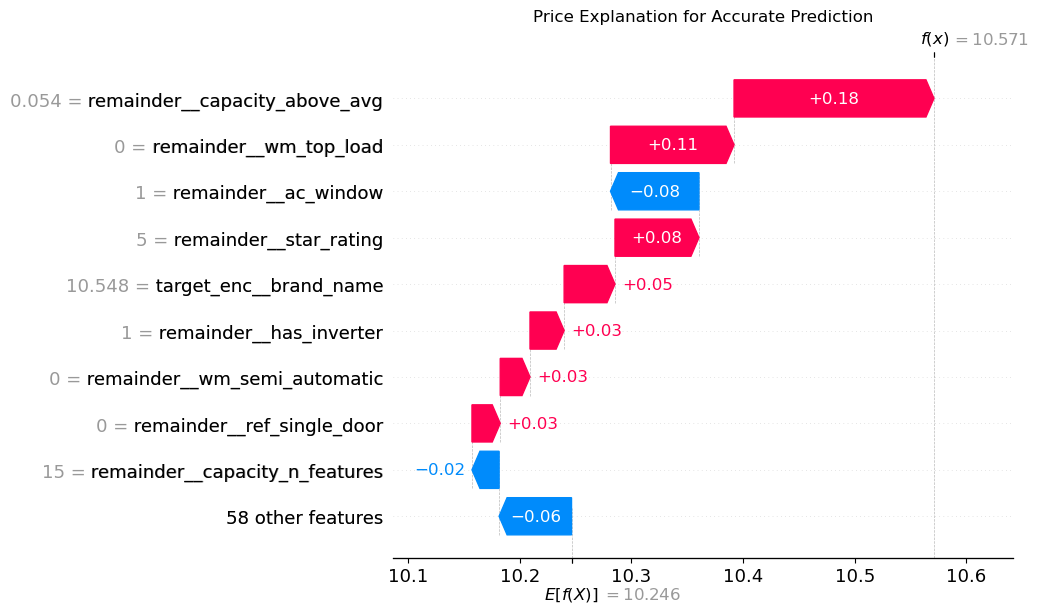

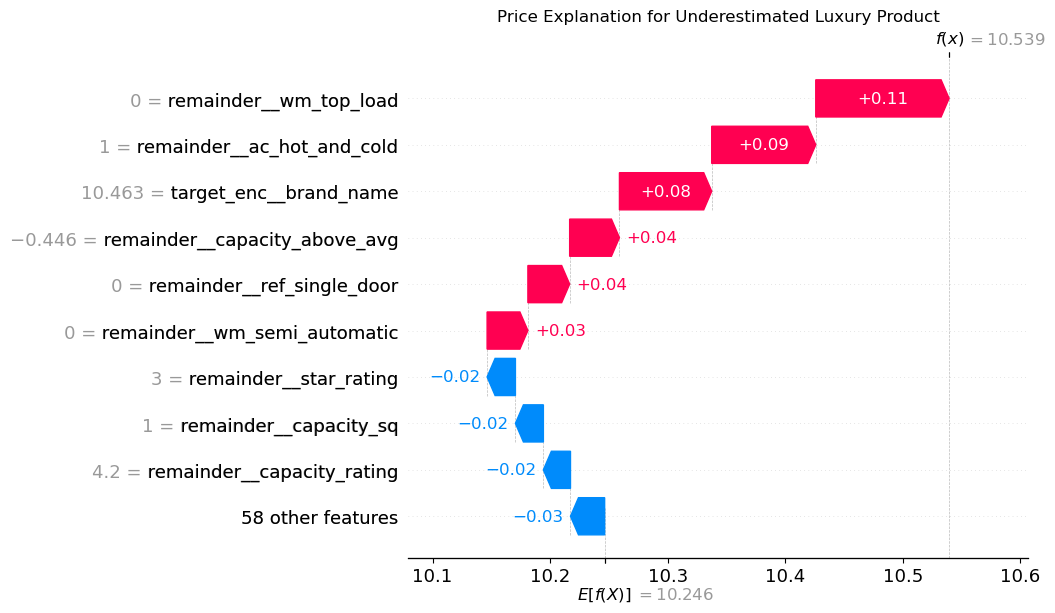

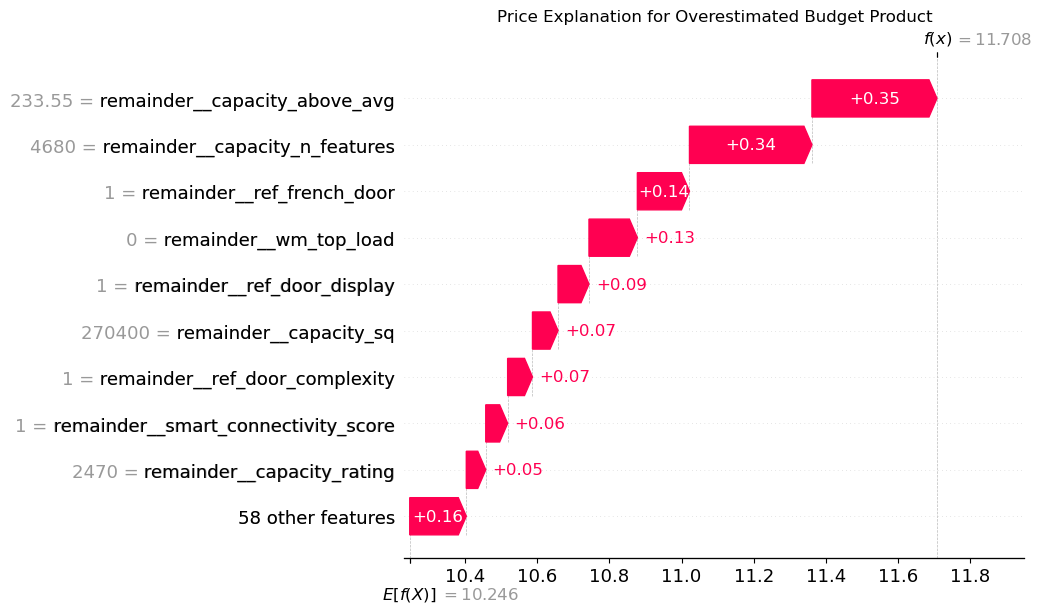

In [9]:
# 0. Setup for Waterfall Plot
y_pred = np.expm1(pipeline.predict(X_test))
y_true = np.expm1(y_test)

analysis_df = X_test.copy()
analysis_df['Actual_Price'] = y_true
analysis_df['Predicted_Price'] = y_pred
analysis_df['Absolute_Error'] = np.abs(analysis_df['Actual_Price'] - analysis_df['Predicted_Price'])

# 1. Identify the top 20 largest absolute errors
top_errors = analysis_df.nlargest(20, 'Absolute_Error')

# We need a SHAP Explanation object for waterfall plots
explainer = shap.TreeExplainer(model)
# Calculate SHAP values for the test set
shap_values_all = explainer(X_test_transformed_df)

# 2. Helper function to plot a specific index
def explain_prediction(index, product_name="Product"):
    shap.plots.waterfall(shap_values_all[index], max_display=10,show=False)
    plt.title(f"Price Explanation for {product_name}")

# --- CASE 1: A reasonably accurate prediction ---
# Find an index where Absolute_Error is low
accurate_idx = analysis_df['Absolute_Error'].nsmallest(5).index[0]
# Map this back to X_test index if necessary
test_idx_accurate = X_test.index.get_loc(accurate_idx) 
explain_prediction(test_idx_accurate, "Accurate Prediction")
plt.show()

# --- CASE 2: A luxury product that was underestimated ---
# Find an index from your 'top_errors' list where Actual > Predicted
underestimated_idx = top_errors[top_errors['Actual_Price'] > top_errors['Predicted_Price']].index[0]
test_idx_under = X_test.index.get_loc(underestimated_idx)
explain_prediction(test_idx_under, "Underestimated Luxury Product")
plt.show()

# --- CASE 3: A budget product that was overestimated ---
# Find an index where Predicted > Actual
overestimated_idx = top_errors[top_errors['Predicted_Price'] > top_errors['Actual_Price']].index[0]
test_idx_over = X_test.index.get_loc(overestimated_idx)
explain_prediction(test_idx_over, "Overestimated Budget Product")
plt.show()

# SHAP Waterfall Plot Interpretations

---

## 1. Accurate Prediction

### Price Explanation for Accurate Prediction

The predicted price was close to the actual price, indicating that the model successfully captured the key drivers influencing the product's value.

**Baseline Prediction**

* Average log-price expectation: **E[f(X)] = 10.246**

### Features Increasing the Predicted Price 📈

| Feature                 | SHAP Contribution | Interpretation                                                                                                           |
| ----------------------- | ----------------: | ------------------------------------------------------------------------------------------------------------------------ |
| `capacity_above_avg`    |             +0.18 | The appliance had a capacity above the dataset average. Larger capacities are generally associated with premium pricing. |
| `wm_top_load = 0`       |             +0.11 | The product was not a top-load washing machine. Front-load or non-top-load designs tend to be priced higher.             |
| `star_rating = 5`       |             +0.08 | A 5-star energy efficiency rating increased the expected price, reflecting premium positioning.                          |
| `target_enc_brand_name` |             +0.05 | The encoded brand value suggested a historically expensive brand.                                                        |
| `has_inverter = 1`      |             +0.03 | Inverter technology slightly increased the predicted price.                                                              |
| `wm_semi_automatic = 0` |             +0.03 | Fully automatic appliances generally command higher prices.                                                              |
| `ref_single_door = 0`   |             +0.03 | Products that are not single-door refrigerators tend to be more expensive.                                               |

### Features Decreasing the Predicted Price 📉

| Feature                 | SHAP Contribution | Interpretation                                                                         |
| ----------------------- | ----------------: | -------------------------------------------------------------------------------------- |
| `ac_window = 1`         |             −0.08 | Window ACs are typically cheaper than split ACs.                                       |
| `capacity_n_features`   |             −0.02 | The interaction between capacity and number of features slightly reduced the estimate. |
| `58 remaining features` |             −0.06 | The combined effect of numerous minor variables modestly lowered the prediction.       |

### Overall Interpretation

* The model balanced both premium and budget signals effectively.
* Strong positive contributions from capacity, efficiency, and brand reputation were partially offset by the window AC characteristic.
* As a result, the final prediction closely matched the actual product price.

---

## 2. Underestimated Luxury Product

### Price Explanation for Underestimated Luxury Product

The model predicted a price lower than the actual value, suggesting that it recognized premium characteristics but failed to fully capture the product's luxury positioning.

**Prediction Summary**

* Baseline expectation: **E[f(X)] = 10.246**
* Final prediction: **f(X) = 10.539**

### Features Increasing the Predicted Price 📈

| Feature                 | SHAP Contribution | Interpretation                                                     |
| ----------------------- | ----------------: | ------------------------------------------------------------------ |
| `wm_top_load = 0`       |             +0.11 | Non-top-load products are generally associated with higher prices. |
| `ac_hot_and_cold = 1`   |             +0.09 | Hot-and-cold functionality is considered a premium feature.        |
| `target_enc_brand_name` |             +0.08 | Historical pricing patterns indicated a premium brand effect.      |
| `capacity_above_avg`    |             +0.04 | Capacity above the dataset average increased expected value.       |
| `ref_single_door = 0`   |             +0.04 | Multi-door refrigerator designs generally carry higher prices.     |
| `wm_semi_automatic = 0` |             +0.03 | Fully automatic products tend to be more expensive.                |

### Features Decreasing the Predicted Price 📉

| Feature                 | SHAP Contribution | Interpretation                                                          |
| ----------------------- | ----------------: | ----------------------------------------------------------------------- |
| `star_rating = 3`       |             −0.02 | A moderate efficiency rating did not support luxury pricing.            |
| `capacity_sq`           |             −0.02 | Nonlinear capacity effects slightly reduced the estimate.               |
| `capacity_rating`       |             −0.02 | The interaction between capacity and efficiency contributed negatively. |
| `58 remaining features` |             −0.03 | Minor variables collectively lowered the prediction.                    |

### Why Was the Product Underestimated?

Although the model identified several premium characteristics, these signals were insufficient to fully explain the product's actual luxury status.

Possible reasons include:

* Brand prestige not fully captured by the encoded variables.
* Unique premium features absent from the dataset.
* Design aesthetics and perceived exclusivity that structured attributes cannot represent.

### Overall Interpretation

* The model correctly recognized the product as expensive.
* However, it underestimated the magnitude of its luxury value, resulting in a lower-than-actual prediction.

---

## 3. Overestimated Budget Product

### Price Explanation for Overestimated Budget Product

This case represents the model's largest overestimation, where multiple premium signals caused the model to predict a substantially higher price than the actual value.

**Prediction Summary**

* Baseline expectation: **E[f(X)] = 10.246**
* Final prediction: **f(X) = 11.708**

### Features Increasing the Predicted Price 📈

| Feature                        | SHAP Contribution | Interpretation                                                                     |
| ------------------------------ | ----------------: | ---------------------------------------------------------------------------------- |
| `capacity_above_avg`           |             +0.35 | Exceptionally large capacity strongly suggested premium pricing.                   |
| `capacity_n_features`          |             +0.34 | The combination of high capacity and numerous features indicated a luxury product. |
| `ref_french_door = 1`          |             +0.14 | French-door refrigerators are commonly positioned as premium appliances.           |
| `wm_top_load = 0`              |             +0.13 | Non-top-load designs are generally associated with higher prices.                  |
| `ref_door_display = 1`         |             +0.09 | Door display panels are often found in premium products.                           |
| `capacity_sq`                  |             +0.07 | Nonlinear capacity effects further increased the estimate.                         |
| `ref_door_complexity = 1`      |             +0.07 | Complex door configurations are typically expensive.                               |
| `smart_connectivity_score = 1` |             +0.06 | Smart connectivity contributed positively to predicted value.                      |
| `capacity_rating`              |             +0.05 | Capacity-related interactions reinforced premium expectations.                     |
| `58 remaining features`        |             +0.16 | Numerous minor variables collectively pushed the prediction upward.                |

### Why Was the Product Overestimated?

The model interpreted several structural characteristics as strong indicators of premium pricing. However, despite possessing these attributes, the product was actually priced much lower.

Possible explanations include:

* Aggressive pricing strategies by the manufacturer.
* Mid-range products adopting premium-looking features.
* Promotional discounts or market competition not reflected in the dataset.

### Overall Interpretation

* The model relied heavily on premium feature combinations that historically signaled expensive products.
* In this instance, those signals proved misleading, leading to substantial overestimation.
* This example highlights the limitations of feature-based pricing models when market pricing strategies deviate from historical patterns.

---
